In [40]:
PRETRAINED_MODEL = "checkpoints/best_model.pth"      
FINAL_MODEL_SAVE = "checkpoints/tuning_1.pth"
TRAIN_LIST = "dataset/tuning/finetune_train_ultimate.txt"      

In [41]:
import torch

In [42]:
BATCH_SIZE = 16          
LEARNING_RATE = 0.0001   
EPOCHS = 10              
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
NUM_WORKERS = 0         

In [7]:
from torch.utils.data import Dataset, DataLoader
import os
import torchaudio
import random

In [8]:
class DeepfakeDataset(Dataset):
    def __init__(self, list_file, max_duration=4, target_sample_rate=16000, is_train=True):
        self.data = []
        self.max_duration = max_duration
        self.target_sample_rate = target_sample_rate
        self.num_samples = max_duration * target_sample_rate
        self.is_train = is_train 

        if not os.path.exists(list_file):
            raise FileNotFoundError(f" Error: File {list_file} tidak ditemukan!")

        with open(list_file, 'r') as f:
            for line in f.readlines():
                parts = line.strip().split()
                if len(parts) >= 2:
                    # Gabungkan kembali path jika ada spasi (case jarang, tapi aman)
                    path = " ".join(parts[:-1])
                    label = int(parts[-1])
                    self.data.append((path, label))
    
    def __len__(self):
        return len(self.data)

    def _pad_or_trim(self, waveform):
        channels, length = waveform.shape
        if length > self.num_samples:
            if self.is_train:
                start = torch.randint(0, length - self.num_samples, (1,)).item()
            else:
                start = (length - self.num_samples) // 2
            waveform = waveform[:, start : start + self.num_samples]
        elif length < self.num_samples:
            pad_amount = self.num_samples - length
            waveform = torch.nn.functional.pad(waveform, (0, pad_amount))
        return waveform

    def __getitem__(self, idx):
        audio_path, label = self.data[idx]
        try:
            waveform, sample_rate = torchaudio.load(audio_path)
        except Exception as e:
            return torch.zeros(1, self.num_samples), torch.tensor(label, dtype=torch.long)

        if sample_rate != self.target_sample_rate:
            resampler = torchaudio.transforms.Resample(sample_rate, self.target_sample_rate)
            waveform = resampler(waveform)

        if waveform.shape[0] > 1:
            waveform = torch.mean(waveform, dim=0, keepdim=True)

        # Augmentasi Noise (Penting buat Fine-Tuning)
        if self.is_train and random.random() < 0.5: 
            noise_amp = 0.005 * torch.rand(1).item() * torch.max(waveform)
            waveform = waveform + noise_amp * torch.randn_like(waveform)

        waveform = self._pad_or_trim(waveform)
        return waveform, torch.tensor(label, dtype=torch.long)

In [9]:
import torch.nn as nn
import torch.optim as optim

In [ ]:
class SimpleAudioCNN(nn.Module):
    def __init__(self):
        super().__init__()
        # Layer Preprocessing (Audio -> Gambar Spectrogram)
        self.spec_layer = torchaudio.transforms.MelSpectrogram(
            sample_rate=16000, n_fft=1024, hop_length=256, n_mels=64
        )
        self.to_db = torchaudio.transforms.AmplitudeToDB()

        # Layer Augmentasi (SpecAugment)
        self.time_mask = torchaudio.transforms.TimeMasking(time_mask_param=30)
        self.freq_mask = torchaudio.transforms.FrequencyMasking(freq_mask_param=15)
        
        # Feature Extractor (CNN)
        self.conv_layers = nn.Sequential(
            # Block 1
            nn.Conv2d(1, 16, 3, padding=1), nn.BatchNorm2d(16), nn.ReLU(), nn.MaxPool2d(2, 2),
            # Block 2
            nn.Conv2d(16, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(), nn.MaxPool2d(2, 2),
            # Block 3
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(), nn.MaxPool2d(2, 2),
            # Block 4
            nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(), 
            nn.AdaptiveAvgPool2d((4, 4)) # Paksa output jadi ukuran 4x4
        )
        
        # Classifier
        self.flatten = nn.Flatten()
        self.fc = nn.Sequential(
            nn.Linear(128 * 4 * 4, 128), 
            nn.ReLU(), 
            nn.Dropout(0.3),
            nn.Linear(128, 2) # Output: [Skor Asli, Skor Palsu]
        )

    def forward(self, x):
        x = self.spec_layer(x)
        x = self.to_db(x)
        x = self.conv_layers(x)
        x = self.flatten(x)
        x = self.fc(x)
        return x

In [47]:
import matplotlib.pyplot as plt
from IPython.display import clear_output
import numpy as np
import time

In [48]:
def run_fine_tuning():

    train_ds = DeepfakeDataset(TRAIN_LIST, is_train=True)
    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS)
    print(f"Total Data Training: {len(train_ds)} sampel")

    # Init Model & Load Pretrained Weights
    model = SimpleAudioCNN().to(DEVICE)
    
    if os.path.exists(PRETRAINED_MODEL):
        print(f"Memuat bobot dari: {PRETRAINED_MODEL}")
        model.load_state_dict(torch.load(PRETRAINED_MODEL, map_location=DEVICE))
    else:
        print("Model lama tidak ditemukan")

    # Optimizer
    optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
    criterion = nn.CrossEntropyLoss()
    
    history_acc = []
    history_loss = []

    # Loop Training
    model.train()

    for epoch in range(EPOCHS):
        total_loss = 0
        correct = 0
        total = 0
        start_time = time.time()
        
        for batch_idx, (inputs, labels) in enumerate(train_loader):
            inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
            
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            total_loss += loss.item()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
            
        # Kalkulasi Metrik
        avg_loss = total_loss / len(train_loader)
        acc = 100. * correct / total
        
        history_loss.append(avg_loss)
        history_acc.append(acc)
        
        # Visualisasi Live
        clear_output(wait=True)
        print(f" Epoch {epoch+1}/{EPOCHS}")
        print(f" Loss: {avg_loss:.4f}")
        print(f" Acc : {acc:.2f}%")
        print(f" Time: {time.time() - start_time:.1f} s")
        
        # Plot Grafik
        plt.figure(figsize=(10, 4))
        
        plt.subplot(1, 2, 1)
        plt.plot(history_loss, color='red', marker='o')
        plt.title('Training Loss')
        plt.grid(True, alpha=0.3)
        
        plt.subplot(1, 2, 2)
        plt.plot(history_acc, color='green', marker='o')
        plt.title('Training Accuracy')
        plt.grid(True, alpha=0.3)
        
        plt.show()

    torch.save(model.state_dict(), FINAL_MODEL_SAVE)
    print(f"\nModel tersimpan di: {FINAL_MODEL_SAVE}")

 Epoch 10/10
 Loss: 0.2849
 Acc : 88.45%
 Time: 29.1 s


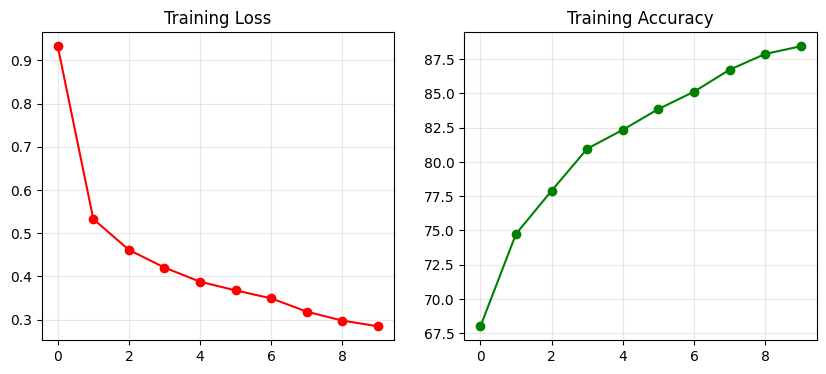


Model tersimpan di: checkpoints/tuning_1.pth


In [49]:
if __name__ == "__main__":
    run_fine_tuning()

In [50]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

TEST_LIST = "dataset/tuning/finetune_test_ultimate.txt"
MODEL_PATH = "checkpoints/tuning_1.pth"

In [51]:
def evaluate_test_set():
    test_ds = DeepfakeDataset(TEST_LIST, is_train=False) 
    test_loader = DataLoader(test_ds, batch_size=16, shuffle=False, num_workers=0)
    
    model = SimpleAudioCNN().to(DEVICE)
    
    model.load_state_dict(torch.load(MODEL_PATH, map_location=DEVICE))

    model.eval()
    all_preds = []
    all_labels = []
    
    correct = 0
    total = 0
    
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
            
            outputs = model(inputs)
            _, predicted = torch.max(outputs.data, 1)
            
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
            
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    if total == 0:
        print("Tidak ada data yang dites.")
        return

    acc = 100 * correct / total
    print(f"FINAL ACCURACY: {acc:.2f}%")
    
    # Classification Report
    target_names = ['Bonafide (Asli)', 'Spoof (AI/Deepfake)']
    print("\nCLASSIFICATION REPORT:")
    print(classification_report(all_labels, all_preds, target_names=target_names))
    
    # Confusion Matrix
    print("CONFUSION MATRIX:")
    cm = confusion_matrix(all_labels, all_preds)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=target_names)
    
    fig, ax = plt.subplots(figsize=(6, 5))
    disp.plot(cmap='Purples', values_format='d', ax=ax)
    plt.title('Evaluasi Model Sakti (Test Set)')
    plt.show()

FINAL ACCURACY: 89.55%

CLASSIFICATION REPORT:
                     precision    recall  f1-score   support

    Bonafide (Asli)       0.84      0.98      0.91       463
Spoof (AI/Deepfake)       0.98      0.80      0.88       427

           accuracy                           0.90       890
          macro avg       0.91      0.89      0.89       890
       weighted avg       0.91      0.90      0.89       890

CONFUSION MATRIX:


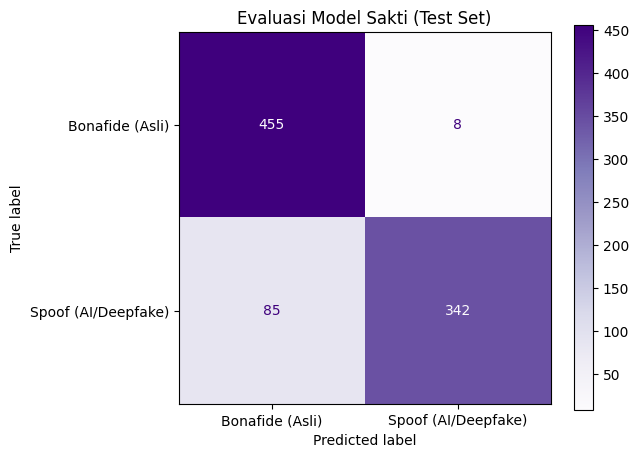

In [52]:
evaluate_test_set()

In [54]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import os
import glob
import torchaudio

In [55]:
INTHEWILD_PATH = "dataset/in_the_wild/" 

MODEL_PATH = "checkpoints/tuning_1.pth" 
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
BATCH_SIZE = 16

In [56]:
def prepare_wild_test_list():
    data = []
    
    # Scan REAL (Label 0)
    real_path = os.path.join(INTHEWILD_PATH, "real")
    if os.path.exists(real_path):
        files = []
        for ext in ['*.wav', '*.mp3', '*.flac']:
            files.extend(glob.glob(os.path.join(real_path, "**", ext), recursive=True))
        
        print(f"   Ditemukan REAL: {len(files)} file")
        for f in files:
            clean = f.replace("\\", "/")
            data.append(f"{clean} 0")
    else:
        print(f"   Folder 'real' tidak ditemukan di dalam {INTHEWILD_PATH}")

    # Scan FAKE (Label 1)
    fake_path = os.path.join(INTHEWILD_PATH, "fake")
    if os.path.exists(fake_path):
        files = []
        for ext in ['*.wav', '*.mp3', '*.flac']:
            files.extend(glob.glob(os.path.join(fake_path, "**", ext), recursive=True))
            
        print(f"   Ditemukan FAKE: {len(files)} file")
        for f in files:
            clean = f.replace("\\", "/")
            data.append(f"{clean} 1")
    else:
        print(f"   Folder 'fake' tidak ditemukan di dalam {INTHEWILD_PATH}")
        
    # Simpan List
    out_file = "test_list_wild.txt"
    with open(out_file, 'w') as f:
        f.write("\n".join(data))
        
    return out_file

In [57]:
def run_wild_evaluation():
    # 1. Generate List
    list_file = prepare_wild_test_list()
    
    # 2. Load Dataset
    try:
        test_ds = DeepfakeDataset(list_file, is_train=False) # is_train=False (Tanpa Noise)
    except NameError:
        print("Class 'DeepfakeDataset' hilang")
        return
    except Exception as e:
        print(f"Error loading dataset: {e}")
        return

    if len(test_ds) == 0:
        print("Dataset kosong")
        return

    test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

    # 3. Load Model
    model = SimpleAudioCNN().to(DEVICE)
    if os.path.exists(MODEL_PATH):
        print(f"Memuat Model: {MODEL_PATH}")
        model.load_state_dict(torch.load(MODEL_PATH, map_location=DEVICE))
    else:
        print(f"Model {MODEL_PATH} tidak ditemukan")
        return

    # 4. Loop Testing
    model.eval()
    all_preds = []
    all_labels = []
    correct = 0
    total = 0
    
    
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
            
            outputs = model(inputs)
            _, predicted = torch.max(outputs.data, 1)
            
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
            
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    # 5. Hasil Akhir
    acc = 100 * correct / total
    print(f"IN-THE-WILD ACCURACY: {acc:.2f}%")
    
    # Confusion Matrix
    target_names = ['Bonafide (Asli)', 'Spoof (Fake)']
    print(classification_report(all_labels, all_preds, target_names=target_names))
    
    cm = confusion_matrix(all_labels, all_preds)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=target_names)
    
    fig, ax = plt.subplots(figsize=(6, 5))
    disp.plot(cmap='Reds', values_format='d', ax=ax)
    plt.title('Confusion Matrix: In-the-Wild Test')
    plt.show()

   Ditemukan REAL: 19963 file
   Ditemukan FAKE: 11816 file
Memuat Model: checkpoints/tuning_1.pth
IN-THE-WILD ACCURACY: 46.50%
                 precision    recall  f1-score   support

Bonafide (Asli)       0.61      0.42      0.50     19963
   Spoof (Fake)       0.35      0.53      0.43     11816

       accuracy                           0.46     31779
      macro avg       0.48      0.48      0.46     31779
   weighted avg       0.51      0.46      0.47     31779



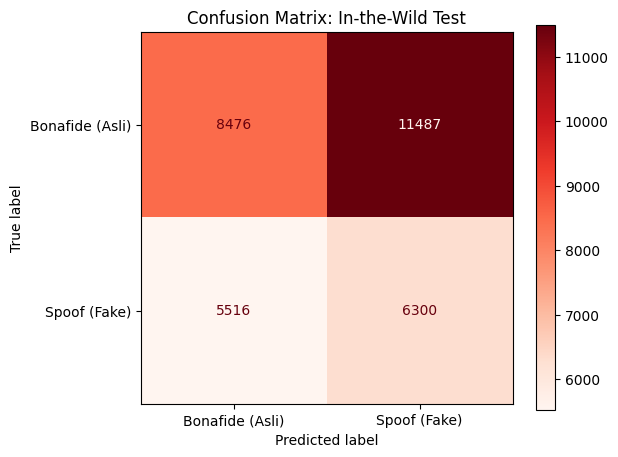

In [58]:
if __name__ == "__main__":
    run_wild_evaluation()

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
import time
import matplotlib.pyplot as plt
from IPython.display import clear_output
import os

In [2]:
PRETRAINED_MODEL = "checkpoints/tuning_1.pth"
FINAL_UNIVERSAL_MODEL = "checkpoints/tuning_2.pth"
TRAIN_LIST = "dataset/final_mix_train.txt"

In [3]:
LEARNING_RATE = 0.0001 
BATCH_SIZE = 16
EPOCHS = 8              
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

In [4]:
def tuning_2():
    # 1. Dataset
    ds = DeepfakeDataset(TRAIN_LIST, is_train=True)
    loader = DataLoader(ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
    
    # 2. Model
    model = SimpleAudioCNN().to(DEVICE)
    if os.path.exists(PRETRAINED_MODEL):
        print(f"Memuat bobot dari: {PRETRAINED_MODEL}")
        model.load_state_dict(torch.load(PRETRAINED_MODEL, map_location=DEVICE))
    else:
        print("Model tidak ada")
        return

    # 3. Optimizer
    optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
    criterion = nn.CrossEntropyLoss()
    
    # List untuk menyimpan history agar bisa di-plot
    history_acc = []
    history_loss = []

    print("Start train")
    
    # 4. Loop Training
    model.train()
    
    for epoch in range(EPOCHS):
        total_loss = 0
        correct = 0
        total = 0
        start_time = time.time()
        
        for inputs, labels in loader:
            inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
            
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            total_loss += loss.item()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
            
        # Hitung rata-rata loss dan akurasi per epoch
        acc = 100. * correct / total
        avg_loss = total_loss / len(loader)
        
        # Simpan ke history
        history_acc.append(acc)
        history_loss.append(avg_loss)
        

        clear_output(wait=True)
        print(f"Epoch {epoch+1}/{EPOCHS}")
        print(f"Loss: {avg_loss:.4f} | Mix Acc: {acc:.2f}%")
        print(f"Time: {time.time() - start_time:.1f}s")
        
        plt.figure(figsize=(12, 5))
        
        # Plot Grafik Loss 
        plt.subplot(1, 2, 1)
        plt.plot(history_loss, label='Train Loss', color='red', marker='o')
        plt.title('Training Loss')
        plt.xlabel('Epoch')
        plt.ylabel('Loss')
        plt.grid(True, alpha=0.3)
        plt.legend()
        
        # Plot Grafik Accuracy 
        plt.subplot(1, 2, 2)
        plt.plot(history_acc, label='Train Accuracy', color='green', marker='x')
        plt.title('Training Accuracy')
        plt.xlabel('Epoch')
        plt.ylabel('Accuracy (%)')
        plt.grid(True, alpha=0.3)
        plt.legend()
        
        plt.show()

    torch.save(model.state_dict(), FINAL_UNIVERSAL_MODEL)
    print(f"\nModel tersimpan di: {FINAL_UNIVERSAL_MODEL}")

Epoch 8/8
Loss: 0.0487 | Mix Acc: 98.28%
Time: 351.1s


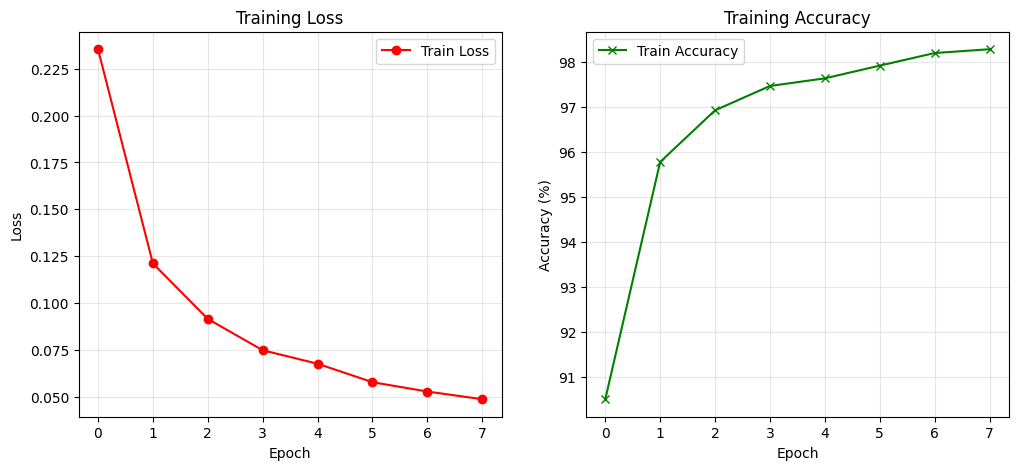


Model tersimpan di: checkpoints/tuning_2.pth


In [11]:
tuning_2()

In [ ]:
import torch
from torch.utils.data import DataLoader
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import os

In [64]:
MODEL_PATH = "checkpoints/tuning_2.pth" 
TEST_LIST = "dataset/final_mix_test.txt"
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
BATCH_SIZE = 16

In [65]:
def run_final_test():

        
    test_ds = DeepfakeDataset(TEST_LIST, is_train=False)
    test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False)

    model = SimpleAudioCNN().to(DEVICE)
    model.load_state_dict(torch.load(MODEL_PATH, map_location=DEVICE))


    model.eval()
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
            outputs = model(inputs)
            _, predicted = torch.max(outputs, 1)
            
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    # 4. Analisis Hasil
    target_names = ['Asli (Real)', 'Palsu (Fake)']
    
    print(classification_report(all_labels, all_preds, target_names=target_names))
    
    # 5. Visualisasi Confusion Matrix
    cm = confusion_matrix(all_labels, all_preds)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=target_names)
    
    fig, ax = plt.subplots(figsize=(7, 6))
    disp.plot(cmap='Blues', values_format='d', ax=ax)
    plt.title('Confusion Matrix: Model Universal vs In-the-Wild')
    plt.show()

              precision    recall  f1-score   support

 Asli (Real)       0.99      1.00      1.00      4011
Palsu (Fake)       1.00      0.99      0.99      2345

    accuracy                           0.99      6356
   macro avg       1.00      0.99      0.99      6356
weighted avg       0.99      0.99      0.99      6356



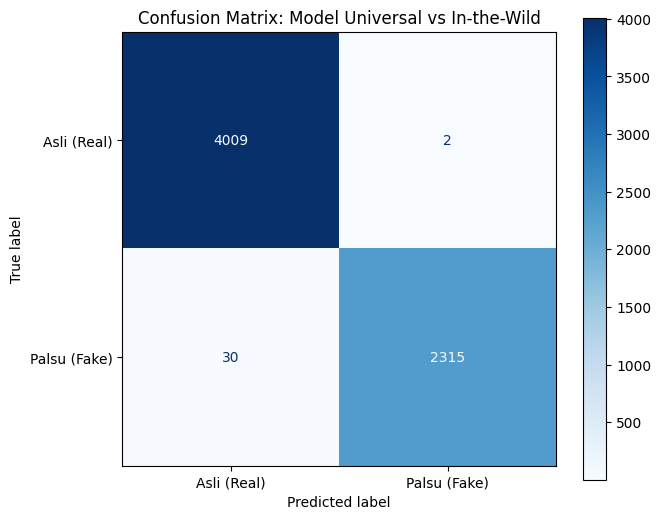

In [66]:
run_final_test()

In [111]:
import torch.nn.functional as F



def predict_single_file(file_path):
    print(f"\nMenganalisa file: {os.path.basename(file_path)}")
    
    if not os.path.exists(file_path):
        print("File tidak ditemukan!")
        return

    # 1. Load Model
    model = SimpleAudioCNN().to(DEVICE)
    model.load_state_dict(torch.load("checkpoints/tuning_1.pth", map_location=DEVICE))
    model.eval()

    # 2. Preprocess (Sama persis dengan training)
    waveform, sample_rate = torchaudio.load(file_path)
    
    # Resample 16k
    if sample_rate != 16000:
        resampler = torchaudio.transforms.Resample(sample_rate, 16000)
        waveform = resampler(waveform)
        
    # Mono
    if waveform.shape[0] > 1:
        waveform = torch.mean(waveform, dim=0, keepdim=True)
        
    # Center Crop 4 detik
    max_len = 16000 * 4
    if waveform.shape[1] > max_len:
        start = (waveform.shape[1] - max_len) // 2
        waveform = waveform[:, start : start + max_len]
    else:
        pad = max_len - waveform.shape[1]
        waveform = F.pad(waveform, (0, pad))
        
    # Add Batch Dim
    input_tensor = waveform.unsqueeze(0).to(DEVICE)

    # 3. Predict
    with torch.no_grad():
        output = model(input_tensor)
        probs = F.softmax(output, dim=1)
        
        score_real = probs[0][0].item() * 100
        score_fake = probs[0][1].item() * 100
        
        pred_idx = torch.argmax(probs, dim=1).item()

    # 4. Hasil
    print("-" * 30)
    if pred_idx == 1:
        print(f"KEPUTUSAN: PALSU / DEEPFAKE")
        print(f"Confidence: {score_fake:.2f}%")
    else:
        print(f"KEPUTUSAN: ASLI / BONAFIDE")
        print(f"Confidence: {score_real:.2f}%")
    print("-" * 30)


TEST_FILE = "dataset/libri+gen/dataset_bonafide_english/6241-61946-0014.flac" 
# Jalankan
predict_single_file(TEST_FILE)


Menganalisa file: 6241-61946-0014.flac
------------------------------
KEPUTUSAN: ASLI / BONAFIDE
Confidence: 98.46%
------------------------------


In [113]:
from sklearn.metrics import accuracy_score

In [ ]:
MODEL_PATH = "checkpoints/tuning_2.pth" 
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
BATCH_SIZE = 16

BENCHMARKS = [
    ("1. XTTS Baseline (Lab)", "dataset/libri+gen/test_list.txt"),
    ("2. Kaggle Multi-Attack", "dataset/tuning/finetune_test_ultimate.txt"),
    ("3. In-the-Wild (Real World)", "dataset/final_mix_test.txt")
]

def run_full_audit():

    model = SimpleAudioCNN().to(DEVICE)
    model.load_state_dict(torch.load(MODEL_PATH, map_location=DEVICE))
    model.eval()


    all_results = {}

    for name, list_file in BENCHMARKS:
        print(f"\nMenguji: {name}")
        
        if not os.path.exists(list_file):
            print(f"    Skip: File '{list_file}' tidak ditemukan.")
            continue

        # Load Dataset (is_train=False agar hasil konsisten/center crop)
        ds = DeepfakeDataset(list_file, is_train=False)
        loader = DataLoader(ds, batch_size=BATCH_SIZE, shuffle=False)
        
        y_true = []
        y_pred = []
        
        with torch.no_grad():
            for inputs, labels in loader:
                inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
                outputs = model(inputs)
                _, predicted = torch.max(outputs, 1)
                
                y_true.extend(labels.cpu().numpy())
                y_pred.extend(predicted.cpu().numpy())
        
        acc = accuracy_score(y_true, y_pred) * 100
        all_results[name] = acc
        
        print(f"   Akurasi: {acc:.4f}%")
        print(classification_report(y_true, y_pred, target_names=['Asli', 'Palsu'], digits=4))

    for name, score in all_results.items():
        status = "SANGAT BAIK" if score > 85 else ("CUKUP" if score > 70 else "LEMAH")
        print(f"{name:<30} | {score:.2f}% | {status}")
    print("-" * 65)

if __name__ == "__main__":
    run_full_audit()


Menguji: 1. XTTS Baseline (Lab)
   Akurasi: 80.0000%
              precision    recall  f1-score   support

        Asli     0.8667    0.7358    0.7959        53
       Palsu     0.7455    0.8723    0.8039        47

    accuracy                         0.8000       100
   macro avg     0.8061    0.8041    0.7999       100
weighted avg     0.8097    0.8000    0.7997       100


Menguji: 2. Kaggle Multi-Attack
   Akurasi: 85.6180%
              precision    recall  f1-score   support

        Asli     0.8131    0.9395    0.8717       463
       Palsu     0.9211    0.7658    0.8363       427

    accuracy                         0.8562       890
   macro avg     0.8671    0.8527    0.8540       890
weighted avg     0.8649    0.8562    0.8547       890


Menguji: 3. In-the-Wild (Real World)
   Akurasi: 99.4965%
              precision    recall  f1-score   support

        Asli     0.9926    0.9995    0.9960      4011
       Palsu     0.9991    0.9872    0.9931      2345

    accuracy   

In [144]:
PRETRAINED_MODEL = "checkpoints/tuning_2.pth" 
TUNING_2_1 = "checkpoints/tuning_2_1.pth"
TRAIN_LIST = "dataset/final_mix_train_balanced.txt"

LEARNING_RATE = 0.0001
EPOCHS = 50

In [145]:
def run_tuning_2_1():
    model = SimpleAudioCNN().to(DEVICE)
    model.load_state_dict(torch.load(PRETRAINED_MODEL, map_location=DEVICE))
    
    ds = DeepfakeDataset(TRAIN_LIST, is_train=True)
    loader = DataLoader(ds, batch_size=BATCH_SIZE, shuffle=True)
    
    optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
    criterion = nn.CrossEntropyLoss()
    
    # List untuk menyimpan history agar bisa di-plot
    history_acc = []
    history_loss = []

    print("Start train")
    
    # 4. Loop Training
    model.train()
    
    for epoch in range(EPOCHS):
        total_loss = 0
        correct = 0
        total = 0
        start_time = time.time()
        
        for inputs, labels in loader:
            inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
            
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            total_loss += loss.item()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
            
        # Hitung rata-rata loss dan akurasi per epoch
        acc = 100. * correct / total
        avg_loss = total_loss / len(loader)
        
        # Simpan ke history
        history_acc.append(acc)
        history_loss.append(avg_loss)
        

        clear_output(wait=True)
        print(f"Epoch {epoch+1}/{EPOCHS}")
        print(f"Loss: {avg_loss:.4f} | Mix Acc: {acc:.2f}%")
        print(f"Time: {time.time() - start_time:.1f}s")
        
        plt.figure(figsize=(12, 5))
        
        # Plot Grafik Loss 
        plt.subplot(1, 2, 1)
        plt.plot(history_loss, label='Train Loss', color='red', marker='o')
        plt.title('Training Loss')
        plt.xlabel('Epoch')
        plt.ylabel('Loss')
        plt.grid(True, alpha=0.3)
        plt.legend()
        
        # Plot Grafik Accuracy 
        plt.subplot(1, 2, 2)
        plt.plot(history_acc, label='Train Accuracy', color='green', marker='x')
        plt.title('Training Accuracy')
        plt.xlabel('Epoch')
        plt.ylabel('Accuracy (%)')
        plt.grid(True, alpha=0.3)
        plt.legend()
        
        plt.show()

    torch.save(model.state_dict(), TUNING_2_1)
    print(f"\nModel tersimpan di: {TUNING_2_1}")

Epoch 50/50
Loss: 0.2912 | Mix Acc: 84.12%
Time: 17.3s


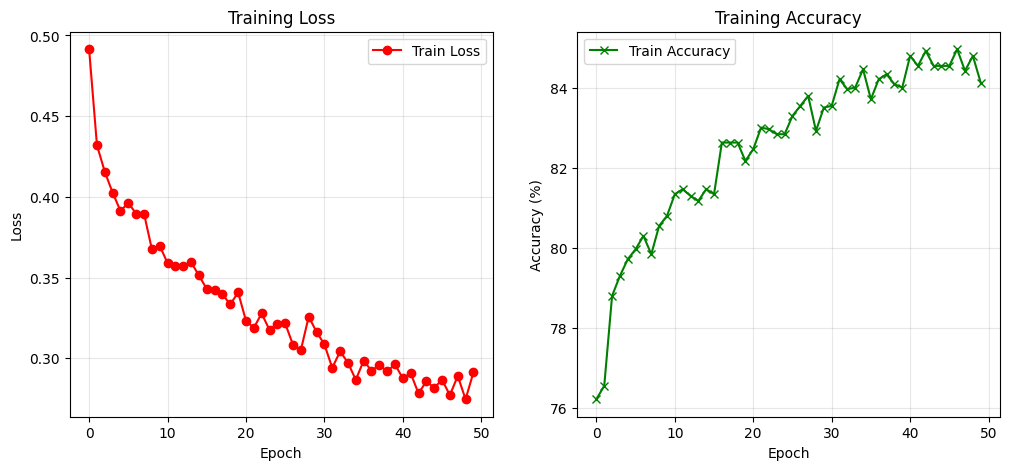


Model tersimpan di: checkpoints/tuning_2_1.pth


In [146]:
run_tuning_2_1()

In [147]:
MODEL_PATH = "checkpoints/tuning_2_1.pth" 
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
BATCH_SIZE = 16

BENCHMARKS = [
    ("1. XTTS Baseline (Lab)", "dataset/libri+gen/test_list.txt"),
    ("2. Kaggle Multi-Attack", "dataset/tuning/finetune_test_ultimate.txt"),
    ("3. In-the-Wild (Real World)", "dataset/final_mix_test.txt")
]

def run_full_audit():

    model = SimpleAudioCNN().to(DEVICE)
    model.load_state_dict(torch.load(MODEL_PATH, map_location=DEVICE))
    model.eval()


    all_results = {}

    for name, list_file in BENCHMARKS:
        print(f"\nMenguji: {name}")
        
        if not os.path.exists(list_file):
            print(f"    Skip: File '{list_file}' tidak ditemukan.")
            continue

        # Load Dataset (is_train=False agar hasil konsisten/center crop)
        ds = DeepfakeDataset(list_file, is_train=False)
        loader = DataLoader(ds, batch_size=BATCH_SIZE, shuffle=False)
        
        y_true = []
        y_pred = []
        
        with torch.no_grad():
            for inputs, labels in loader:
                inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
                outputs = model(inputs)
                _, predicted = torch.max(outputs, 1)
                
                y_true.extend(labels.cpu().numpy())
                y_pred.extend(predicted.cpu().numpy())
        
        acc = accuracy_score(y_true, y_pred) * 100
        all_results[name] = acc
        
        print(f"   Akurasi: {acc:.4f}%")
        print(classification_report(y_true, y_pred, target_names=['Asli', 'Palsu'], digits=4))

    for name, score in all_results.items():
        status = "SANGAT BAIK" if score > 85 else ("CUKUP" if score > 70 else "LEMAH")
        print(f"{name:<30} | {score:.2f}% | {status}")
    print("-" * 65)

if __name__ == "__main__":
    run_full_audit()


Menguji: 1. XTTS Baseline (Lab)
   Akurasi: 95.0000%
              precision    recall  f1-score   support

        Asli     0.9615    0.9434    0.9524        53
       Palsu     0.9375    0.9574    0.9474        47

    accuracy                         0.9500       100
   macro avg     0.9495    0.9504    0.9499       100
weighted avg     0.9502    0.9500    0.9500       100


Menguji: 2. Kaggle Multi-Attack
   Akurasi: 91.0112%
              precision    recall  f1-score   support

        Asli     0.8593    0.9892    0.9197       463
       Palsu     0.9860    0.8244    0.8980       427

    accuracy                         0.9101       890
   macro avg     0.9226    0.9068    0.9088       890
weighted avg     0.9201    0.9101    0.9093       890


Menguji: 3. In-the-Wild (Real World)
   Akurasi: 87.2089%
              precision    recall  f1-score   support

        Asli     0.9400    0.8517    0.8937      4011
       Palsu     0.7814    0.9070    0.8396      2345

    accuracy   